# Introduction to Machine Learning with PyTorch
## Project: Finding Donors for *CharityML*

In [42]:
# Python version
!python --version

Python 3.12.12


## Getting Started

In this project, we will employ several supervised algorithms to accurately model individuals' income using data collected from the 1994 U.S. Census. We will then choose the best candidate algorithm(s) from preliminary results and further optimize this algorithm(s) to best model the data. Our goal with this implementation is to construct a model that accurately predicts whether an individual makes more than $50,000. This sort of task can arise in a non-profit setting, where organizations survive on donations.  Understanding an individual's income can help a non-profit better understand how large of a donation to request, or whether or not they should reach out to begin with.  While it can be difficult to determine an individual's general income bracket directly from public sources, we can (as we will see) infer this value from other publically available features.

The dataset for this project originates from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Census+Income). The datset was donated by Ron Kohavi and Barry Becker, after being published in the article _"Scaling Up the Accuracy of Naive-Bayes Classifiers: A Decision-Tree Hybrid"_. You can find the article by Ron Kohavi [online](https://www.aaai.org/Papers/KDD/1996/KDD96-033.pdf). The data we investigate here consists of small changes to the original dataset, such as removing the `fnlwgt` feature and records with missing or ill-formatted entries.

----
## Exploring the Data
`income`, will be our target label (whether an individual makes more than, or at most, $50,000 annually). All other columns are features about each individual in the census database.

In [43]:
!wget https://storage.googleapis.com/data_files_soliman/udacity/intro_machine_learning/visuals.py

--2025-12-15 13:09:08--  https://storage.googleapis.com/data_files_soliman/udacity/intro_machine_learning/visuals.py
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.107.207, 74.125.142.207, 173.194.202.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.107.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5663 (5.5K) [text/x-python]
Saving to: ‘visuals.py.1’

visuals.py.1        100%[===================>]   5.53K  --.-KB/s    in 0s      

2025-12-15 13:09:09 (54.6 MB/s) - ‘visuals.py.1’ saved [5663/5663]



In [44]:
# Import libraries necessary for this project
import numpy as np
import pandas as pd
from time import time
from IPython.display import display # Allows the use of display() for DataFrames

# Import supplementary visualization code visuals.py
import visuals as vs

import warnings
warnings.filterwarnings('ignore')

# Pretty display for notebooks
%matplotlib inline



In [45]:
URL = "https://storage.googleapis.com/data_files_soliman/udacity/intro_machine_learning/census.csv"

# Load the Census dataset
data = pd.read_csv(URL)

# Display a random record
data.sample(1)

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
8116,20,Private,Some-college,10.0,Never-married,Farming-fishing,Own-child,White,Male,0.0,0.0,60.0,United-States,<=50K


In [46]:
data.income.value_counts()

,count
income,
<=50K,34014
>50K,11208


### Implementation: Data Exploration
A cursory investigation of the dataset will determine how many individuals fit into either group, and will tell us about the percentage of these individuals making more than $50,000.

In [47]:
# Total number of records
n_records = data.shape[0]

# Number of records where individual's income is more than $50,000
n_greater_50k = data[data['income'] == '>50K'].shape[0]

# Number of records where individual's income is at most $50,000
n_at_most_50k =  data[data['income'] == '<=50K'].shape[0]

# Percentage of individuals whose income is more than $50,000
greater_percent = n_greater_50k / n_records * 100

# Print the results
print("Total number of records: {}".format(n_records))
print("Individuals making more than $50,000: {}".format(n_greater_50k))
print("Individuals making at most $50,000: {}".format(n_at_most_50k))
print("Percentage of individuals making more than $50,000: {:.2f}%".format(greater_percent))

Total number of records: 45222
Individuals making more than $50,000: 11208
Individuals making at most $50,000: 34014
Percentage of individuals making more than $50,000: 24.78%


In [48]:
data.sample(1)

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
17843,40,Private,Bachelors,13.0,Married-spouse-absent,Exec-managerial,Not-in-family,White,Male,0.0,0.0,40.0,United-States,>50K


**Featureset Exploration**

* **age**: continuous.
* **workclass**: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
* **education**: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
* **education-num**: continuous.
* **marital-status**: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
* **occupation**: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
* **relationship**: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
* **race**: Black, White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other.
* **sex**: Female, Male.
* **capital-gain**: continuous.
* **capital-loss**: continuous.
* **hours-per-week**: continuous.
* **native-country**: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

----
## Preparing the Data
Before data can be used as input for machine learning algorithms, it often must be cleaned, formatted, and restructured — this is typically known as **preprocessing**.

In [49]:
# Check missed values
data.isnull().sum().sum()

# No missed values.

np.int64(0)

In [50]:
data.duplicated().sum()

np.int64(5982)

In [51]:
# Remove duplicates
data.drop_duplicates(
    subset=None,
    keep='first',
    inplace=True,
    ignore_index=True
)


In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39240 entries, 0 to 39239
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              39240 non-null  int64  
 1   workclass        39240 non-null  object 
 2   education_level  39240 non-null  object 
 3   education-num    39240 non-null  float64
 4   marital-status   39240 non-null  object 
 5   occupation       39240 non-null  object 
 6   relationship     39240 non-null  object 
 7   race             39240 non-null  object 
 8   sex              39240 non-null  object 
 9   capital-gain     39240 non-null  float64
 10  capital-loss     39240 non-null  float64
 11  hours-per-week   39240 non-null  float64
 12  native-country   39240 non-null  object 
 13  income           39240 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 4.2+ MB


In [53]:
data.describe(include='object')

,workclass,education_level,marital-status,occupation,relationship,race,sex,native-country,income
count,39240,39240,39240,39240,39240,39240,39240,39240,39240
unique,7,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,27717,12003,17947,5516,15645,33064,26097,35340,29265


In [54]:
data.describe(exclude='object')

,age,education-num,capital-gain,capital-loss,hours-per-week
count,39240.000000,39240.000000,39240.000000,39240.000000,39240.000000
mean,39.309225,10.136290,1253.314246,101.261340,41.206091
std,13.298041,2.637194,7993.997264,431.434412,12.458021
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,29.000000,9.000000,0.000000,0.000000,40.000000
50%,38.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


### Transforming Skewed Continuous Features
A dataset may sometimes contain at least one feature whose values tend to lie near a single number, but will also have a non-trivial number of vastly larger or smaller values than that single number.  Algorithms can be sensitive to such distributions of values and can underperform if the range is not properly normalized. With the census dataset two features fit this description: `capital-gain` and `capital-loss`.


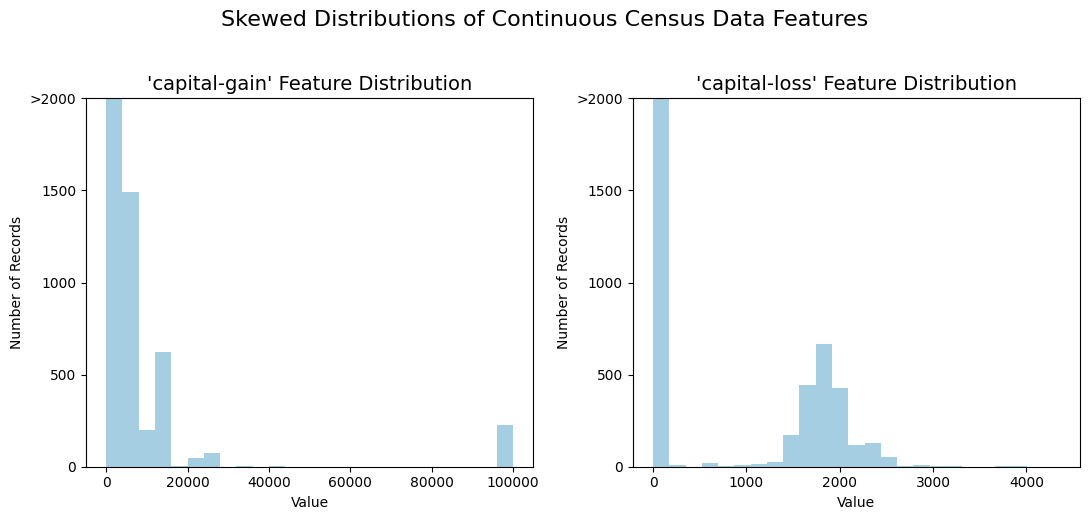

In [55]:
# Split the data into features and target label
income_raw = data['income'] #target
features_raw = data.drop('income', axis = 1) #features

# Visualize skewed continuous features of original data
vs.distribution(data)

For highly-skewed feature distributions such as `capital-gain` and `capital-loss`, it is common practice to apply a [logarithmic transformation](https://en.wikipedia.org/wiki/Data_transformation_(statistics)) on the data so that the very large and very small values do not negatively affect the performance of a learning algorithm. Using a logarithmic transformation significantly reduces the range of values caused by outliers. Care must be taken when applying this transformation however: The logarithm of 0 is undefined, so we must translate the values by a small amount above 0 to apply the the logarithm successfully.


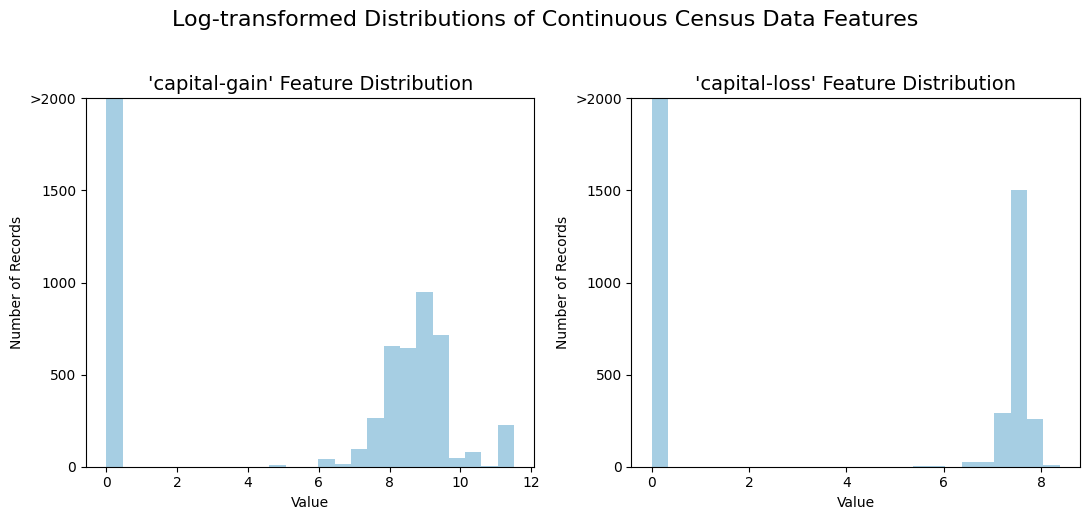

In [56]:
# Log-transform the skewed features
skewed = ['capital-gain', 'capital-loss']
features_log_transformed = pd.DataFrame(data = features_raw)

# features_log_transformed[skewed] = features_raw[skewed].apply(lambda x: np.log(x + 1))
features_log_transformed[skewed] = np.log(features_raw[skewed] + 1)


# Visualize the new log distributions
vs.distribution(features_log_transformed, transformed = True)

### Normalizing Numerical Features
In addition to performing transformations on features that are highly skewed, it is often good practice to perform some type of scaling on numerical features. Applying a scaling to the data does not change the shape of each feature's distribution (such as `capital-gain` or `capital-loss` above); however, normalization ensures that each feature is treated equally when applying supervised learners. Note that once scaling is applied, observing the data in its raw form will no longer have the same original meaning, as exampled below.



In [57]:
features_log_transformed

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,7.684784,0.0,40.0,United-States
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,13.0,United-States
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,40.0,United-States
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,40.0,United-States
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,40.0,Cuba
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39235,48,Local-gov,Masters,14.0,Divorced,Other-service,Not-in-family,White,Male,0.000000,0.0,40.0,United-States
39236,33,Private,Bachelors,13.0,Never-married,Prof-specialty,Own-child,White,Male,0.000000,0.0,40.0,United-States
39237,39,Private,Bachelors,13.0,Divorced,Prof-specialty,Not-in-family,White,Female,0.000000,0.0,36.0,United-States
39238,44,Private,Bachelors,13.0,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,8.604471,0.0,40.0,United-States


In [58]:
# Import sklearn.preprocessing.StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Initialize a scaler, then apply it to the features
scaler = MinMaxScaler() # default=(0, 1)

numerical = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

features_log_minmax_transform = pd.DataFrame(data = features_log_transformed)
features_log_minmax_transform[numerical] = scaler.fit_transform(features_log_transformed[numerical])

# Show an example of a record with scaling applied
features_log_minmax_transform.head(5)

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,0.301370,State-gov,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.667492,0.0,0.397959,United-States
1,0.452055,Self-emp-not-inc,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,0.122449,United-States
2,0.287671,Private,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,0.397959,United-States
3,0.493151,Private,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,0.397959,United-States
4,0.150685,Private,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,0.397959,Cuba


### Implementation: Data Preprocessing

From the table in **Exploring the Data** above, we can see there are several features for each record that are non-numeric. Typically, learning algorithms expect input to be numeric, which requires that non-numeric features (called *categorical variables*) be converted. One popular way to convert categorical variables is by using the **one-hot encoding** scheme.

In [59]:
data.columns

Index(['age', 'workclass', 'education_level', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [60]:
data['income']

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K
...,...
39235,<=50K
39236,<=50K
39237,<=50K
39238,<=50K


In [61]:
# one-hot encoding
features_final = pd.get_dummies(features_log_minmax_transform, drop_first=True)

bool_cols = features_final.select_dtypes(include='bool').columns

features_final[bool_cols] = features_final[bool_cols].astype(int)


# Encode the 'income_raw' data to numerical values
# income = np.where(income_raw == '>50K', 1, 0)
data['income'] = (data['income'] == '>50K').astype(int)

# Print the number of features after one-hot encoding
encoded = list(features_final.columns)
print("{} total features after one-hot encoding.".format(len(encoded)))

# Check the encoded feature names
encoded

95 total features after one-hot encoding.


['age',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'workclass_ Local-gov',
 'workclass_ Private',
 'workclass_ Self-emp-inc',
 'workclass_ Self-emp-not-inc',
 'workclass_ State-gov',
 'workclass_ Without-pay',
 'education_level_ 11th',
 'education_level_ 12th',
 'education_level_ 1st-4th',
 'education_level_ 5th-6th',
 'education_level_ 7th-8th',
 'education_level_ 9th',
 'education_level_ Assoc-acdm',
 'education_level_ Assoc-voc',
 'education_level_ Bachelors',
 'education_level_ Doctorate',
 'education_level_ HS-grad',
 'education_level_ Masters',
 'education_level_ Preschool',
 'education_level_ Prof-school',
 'education_level_ Some-college',
 'marital-status_ Married-AF-spouse',
 'marital-status_ Married-civ-spouse',
 'marital-status_ Married-spouse-absent',
 'marital-status_ Never-married',
 'marital-status_ Separated',
 'marital-status_ Widowed',
 'occupation_ Armed-Forces',
 'occupation_ Craft-repair',
 'occupation_ Exec-managerial',
 'occupation_ F

In [62]:
features_final

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,0.301370,0.800000,0.667492,0.0,0.397959,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1,0.452055,0.800000,0.000000,0.0,0.122449,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,0.287671,0.533333,0.000000,0.0,0.397959,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0.493151,0.400000,0.000000,0.0,0.397959,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0.150685,0.800000,0.000000,0.0,0.397959,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39235,0.424658,0.866667,0.000000,0.0,0.397959,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
39236,0.219178,0.800000,0.000000,0.0,0.397959,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
39237,0.301370,0.800000,0.000000,0.0,0.357143,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
39238,0.369863,0.800000,0.747375,0.0,0.397959,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [63]:
# type(data['income'])

In [64]:
# data['income'].to_frame()
data['income']

,income
0,0
1,0
2,0
3,0
4,0
...,...
39235,0
39236,0
39237,0
39238,0


### Shuffle and Split Data
Now all _categorical variables_ have been converted into numerical features, and all numerical features have been normalized. As always, we will now split the data (both features and their labels) into training and test sets. 80% of the data will be used for training and 20% for testing.

In [65]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the 'features' and 'income' data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_final,
                                                    data['income'],
                                                    test_size = 0.2,
                                                    random_state = 0, shuffle= True)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 31392 samples.
Testing set has 7848 samples.


----
## Evaluating Model Performance
In this section, we will investigate four different algorithms, and determine which is best at modeling the data. Three of these algorithms will be supervised learners of your choice, and the fourth algorithm is known as a *naive predictor*.

### Metrics and the Naive Predictor
**CharityML**, equipped with their research, knows individuals that make more than 50,000 are most likely to donate to their charity. Because of this, **CharityML** is particularly interested in predicting who makes more than 50,000 accurately. It would seem that using **accuracy** as a metric for evaluating a particular model's performace would be appropriate. Additionally, identifying someone that **does not** make more than 50,000 as someone who does would be detrimental to **CharityML**, since they are looking to find individuals willing to donate. Therefore, a model's ability to precisely predict those that make more than 50,000 is **more important** than the model's ability to **recall** those individuals. We can use **F-beta score** as a metric that considers both precision and recall:

$$ F_{\beta} = (1 + \beta^2) \cdot \frac{\text{precision} \cdot \text{recall}}{\left( \beta^2 \cdot \text{precision} \right) + \text{recall}} $$

In particular, when $\beta = 0.5$, more emphasis is placed on precision. This is called the $F_{0.5}$ score (or F-score for simplicity).

Looking at the distribution of classes (those who make at most 50,000, and those who make more), it's clear most individuals do not make more than 50,000. This can greatly affect **accuracy**, since we could simply say **"this person does not make more than 50,000"** and generally be right, without ever looking at the data! Making such a statement would be called **naive**, since we have not considered any information to substantiate the claim. It is always important to consider the **naive prediction** for your data, to help establish a benchmark for whether a model is performing well. That been said, using that prediction would be pointless: If we predicted all people made less than 50,000, **CharityML** would identify no one as donors.


#### Note: Recap of accuracy, precision, recall

**Accuracy** measures how often the classifier makes the correct prediction. It’s the ratio of the number of correct predictions to the total number of predictions (the number of test data points).

**Precision** tells us what proportion of messages we classified as spam, actually were spam.
It is a ratio of true positives (words classified as spam, and which are actually spam) to all positives (all words classified as spam, irrespective of whether that was the correct classificatio), in other words it is the ratio of

$$\text{Precision} = \frac{\text{True Positives}} {\text{True Positives} + \text{False Positives}}$$

**Recall (sensitivity)** tells us what proportion of messages that actually were spam were classified by us as spam.
It is a ratio of true positives (words classified as spam, and which are actually spam) to all the words that were actually spam, in other words it is the ratio of

$$\text{Recall} = \frac{\text{True Positives}} {\text{True Positives} + \text{False Negatives}}$$

For classification problems that are skewed in their classification distributions, like in our case, for example, if we had 100 text messages and only 2 were spam and the remaining 98 weren't, accuracy is not a very good metric. We could classify 90 messages as not spam (including the 2 that were spam, but we classify them as not spam, hence they would be false negatives) and 10 as spam (all 10 false positives) and still get a reasonably good accuracy score. For such cases, precision and recall come in very handy. These two metrics can be combined to get the F1 score and the weighted average (harmonic mean) of the precision and recall scores. This score can range from 0 to 1, with 1 being the best possible F1 score(we take the harmonic mean when dealing with ratios).

### Question 1 - Naive Predictor Performace
* If we chose a model that always predicted an individual made more than $50,000, what would  that model's accuracy and F-score be on this dataset?

**Please note** that the the purpose of generating a naive predictor is simply to show what a base model without any intelligence would look like. In the real world, ideally your base model would be either the results of a previous model or could be based on a research paper upon which you are looking to improve. When there is no benchmark model set, getting a result better than random choice is a place you could start from.


In [66]:
income = data['income']

In [67]:
TP = np.sum(income) # Counting the ones as this is the naive case. Note that 'income' is the 'income_raw' data encoded to numerical values done in the data preprocessing step.
FP = income.count() - TP # Specific to the naive case

TN = 0 # No predicted negatives in the naive case
FN = 0 # No predicted negatives in the naive case

# TODO: Calculate accuracy, precision and recall
accuracy = (TP + TN ) / (TP + TN + FP + FN)
recall = TP / (TP + FN)
precision = TP / (TP + FP)

# TODO: Calculate F-score using the formula above for beta = 0.5 and correct values for precision and recall.
fscore = (1 + 0.5**2) * (precision * recall) / (0.5**2 * precision + recall)

# Print the results
print("Naive Predictor: [Accuracy score: {:.4f}, F-score: {:.4f}]".format(accuracy, fscore))

Naive Predictor: [Accuracy score: 0.2542, F-score: 0.2988]


###  Supervised Learning Models


### Question 2 - Model Application
List three of the supervised learning models above that are appropriate for this problem that you will test on the census data. For each model chosen

- Describe one real-world application in industry where the model can be applied.
- What are the strengths of the model; when does it perform well?
- What are the weaknesses of the model; when does it perform poorly?
- What makes this model a good candidate for the problem, given what you know about the data?



-   We had chosen the following Algorithms:
    -   Logistic Regression
    -   KNN
    -   Random Forest (Ensemble/ Bagging)

Based on our choice of models for the **Finding Donors for *CharityML*** project, here is an analysis of Logistic Regression, K-Nearest Neighbors (KNN), and Random Forest.

### **Model 1: Logistic Regression**

-   **Describe one real-world application in industry where the model can be applied.** Logistic Regression is widely used in **Finance** for **Credit Scoring**, where it predicts the probability of a borrower defaulting on a loan based on factors like income, employment history, and credit history. It is also commonly used for disease prediction in **Healthcare**.[1][2][3]

-   **What are the strengths of the model; when does it perform well?**

    -   **Interpretability:** It is considered a "white box" model, which is easy to understand, implement, and interpret. The coefficients reveal the magnitude and direction (positive or negative) of a feature's association with the outcome's log-odds.[4]
    -   **Efficiency and Speed:** It is computationally efficient and fast to train and classify unknown records, making it suitable for large datasets.[5]
    -   **Probabilistic Output:** It naturally outputs a probability (a value between 0 and 1) for the positive class, which is highly useful for risk assessment and decision-making.[4]
-   **What are the weaknesses of the model; when does it perform poorly?**

    -   **Linearity Assumption:** It assumes a linear relationship between the independent variables and the log-odds of the outcome, meaning it may fail to capture complex, non-linear relationships in the data.
    -   **Sensitivity to Data:** It can be sensitive to outliers and requires a low degree of multicollinearity between independent variables.
    -   **Limited Power:** It can be easily outperformed by more powerful, complex algorithms like Neural Networks when dealing with non-linearly separable or highly complex datasets.[3]
-   **What makes this model a good candidate for the problem, given what you know about the data?** The most significant advantage for the *CharityML* problem is its **interpretability**. A non-profit would greatly benefit from knowing *why* a potential donor is likely to have a high income (e.g., which features have the highest positive coefficients), allowing for better-informed, targeted outreach strategies. Additionally, the dataset, after one-hot encoding, is high-dimensional but sparse, which Logistic Regression, especially with regularization, can handle efficiently.[4]

* * * * *

### **Model 2: K-Nearest Neighbors (KNN)**

-   **Describe one real-world application in industry where the model can be applied.** KNN is used in **Recommender Systems** to suggest items to a user based on the purchases or preferences of their "nearest neighbors" (users with similar behaviors). It is also applied in **Image Classification** and **Medical Diagnosis**.[6][7]

-   **What are the strengths of the model; when does it perform well?**

    -   **Simplicity and Non-parametric Nature:** It is a simple, intuitive, non-parametric model, meaning it makes no assumptions about the underlying data distribution and can capture highly irregular decision boundaries.[6]
    -   **No Training Phase:** As a "lazy learner," it has no dedicated training phase (it just stores the data), making the training step extremely fast.
    -   **Adaptability:** It can easily adapt to new training data without requiring a full model re-training.
-   **What are the weaknesses of the model; when does it perform poorly?**

    -   **Computational Expense at Prediction:** Prediction time can be slow, especially with large datasets, because it must calculate the distance between the new data point and *every* point in the training set.[6]
    -   **Curse of Dimensionality:** It performs poorly in high-dimensional spaces (many features), as the distance metric becomes less meaningful.
    -   **Sensitivity:** It is highly sensitive to the scale of features and struggles with imbalanced datasets.
-   **What makes this model a good candidate for the problem, given what you know about the data?** The most crucial factor is that the data has already been **preprocessed and scaled** using Min-Max scaling. Since KNN relies entirely on distance calculations, this required scaling ensures that no single feature dominates the distance metric. If the relationship between features and high income is highly non-linear or local, KNN's non-parametric nature may find patterns that linear models miss.[6]

* * * * *

### **Model 3: Random Forest**

-   **Describe one real-world application in industry where the model can be applied.** Random Forest is a strong, versatile model used extensively in **Banking and Finance** for **Fraud Detection** and making credit or lending decisions. It is also used in **E-commerce** and **Marketing** for predicting customer churn or retention rates.[8][9]

-   **What are the strengths of the model; when does it perform well?**

    -   **High Accuracy and Robustness:** As an ensemble of decision trees, it aggregates predictions to achieve high accuracy and excellent generalization.[9]
    -   **Resilience to Overfitting and Noise:** By training individual trees on random subsets of data and features (bagging and feature randomness), it significantly reduces the risk of overfitting compared to a single decision tree and is robust to outliers and noisy data.[9]
    -   **Feature Importance:** It easily provides a ranking of feature importance, which can be used to select the most relevant predictors.[8]
    -   **Handles Data Types:** It works well with both classification and regression tasks and handles a mix of numerical and categorical data naturally.
-   **What are the weaknesses of the model; when does it perform poorly?**

    -   **Lack of Interpretability (Black-Box):** The ensemble nature (combining hundreds of trees) makes it difficult to trace the logic and understand the specific reason for a single prediction, rendering it less interpretable than simpler models.[4]
    -   **Computational Cost:** Training and prediction can be computationally intensive and slower than simpler algorithms due to the need to build and run multiple independent decision trees.
    -   **Resource Requirements:** It requires more memory and computational resources to store and process a large number of trees.
-   **What makes this model a good candidate for the problem, given what you know about the data?** The data contains a high number of features after one-hot encoding. Random Forest handles this high-dimensional feature space effectively and provides **feature importance scores**. For *CharityML*, this score is valuable for identifying the **strongest socioeconomic predictors** of high income, which aids in future marketing design. Furthermore, its high accuracy and robustness make it an ideal choice for a problem where **Precision** (measured via F-beta score, \(\beta=0.5\)) is critical, as a highly accurate model is best positioned to minimize the costly error of labeling a non-donor as a potential donor.[8]

[1](https://repository.up.ac.za/server/api/core/bitstreams/6551cc01-75d4-4213-9696-dc382cb38a06/content)
[2](https://caf.journals.ekb.eg/article_351751.html)
[3](https://www.sciencedirect.com/science/article/abs/pii/S0957417422017511)
[4](https://es.mathworks.com/help/risk/creditscorecard-compare-logistic-regression-decision-trees.html)
[5](https://ceur-ws.org/Vol-4005/paper13.pdf)
[6](https://pyimagesearch.com/2016/08/08/k-nn-classifier-for-image-classification/)
[7](https://ijece.iaescore.com/index.php/IJECE/article/download/24045/15271)
[8](https://publikasi.dinus.ac.id/index.php/jcta/article/view/9462)
[9](https://fraud-detection-handbook.github.io/fraud-detection-handbook/Chapter_6_ImbalancedLearning/Ensembling.html)
[10](https://www.diva-portal.org/smash/get/diva2:1833653/FULLTEXT01.pdf)

### Implementation - Creating a Training and Predicting Pipeline
To properly evaluate the performance of each model we've chosen, it's important that we create a training and predicting pipeline that allows us to quickly and effectively train models using various sizes of training data and perform predictions on the testing data.

In [68]:
# Import necessary modules: time is needed for timing, and the metrics are for evaluation.
from time import time
from sklearn.metrics import fbeta_score, accuracy_score

def train_predict(learner, sample_size, X_train, y_train, X_test, y_test):
    '''
    inputs:
        - learner: the learning algorithm to be trained and predicted on
        - sample_size: the size of samples (number) to be drawn from training set
        - X_train: features training set
        - y_train: income training set
        - X_test: features testing set
        - y_test: income testing set
    '''

    results = {}

    start = time() # Get start time

    learner.fit(X_train[:sample_size], y_train[:sample_size])

    end = time() # Get end time

    results['train_time'] = end - start

    start = time() # Get start time
    # Get predictions on test set
    predictions_test = learner.predict(X_test)
    # Get predictions on the first 300 training samples
    predictions_train = learner.predict(X_train[:300])
    end = time() # Get end time

    results['pred_time'] = end - start

    results['acc_train'] = accuracy_score(y_train[:300], predictions_train)

    results['acc_test'] = accuracy_score(y_test, predictions_test)

    results['f_train'] = fbeta_score(y_train[:300], predictions_train, beta=0.5)

    results['f_test'] = fbeta_score(y_test, predictions_test, beta=0.5)

    # Success
    print("{} trained on {} samples.".format(learner.__class__.__name__, sample_size))

    return results

### Implementation: Initial Model Evaluation


LogisticRegression trained on 313 samples.
LogisticRegression trained on 3139 samples.
LogisticRegression trained on 31392 samples.
KNeighborsClassifier trained on 313 samples.
KNeighborsClassifier trained on 3139 samples.
KNeighborsClassifier trained on 31392 samples.
RandomForestClassifier trained on 313 samples.
RandomForestClassifier trained on 3139 samples.
RandomForestClassifier trained on 31392 samples.


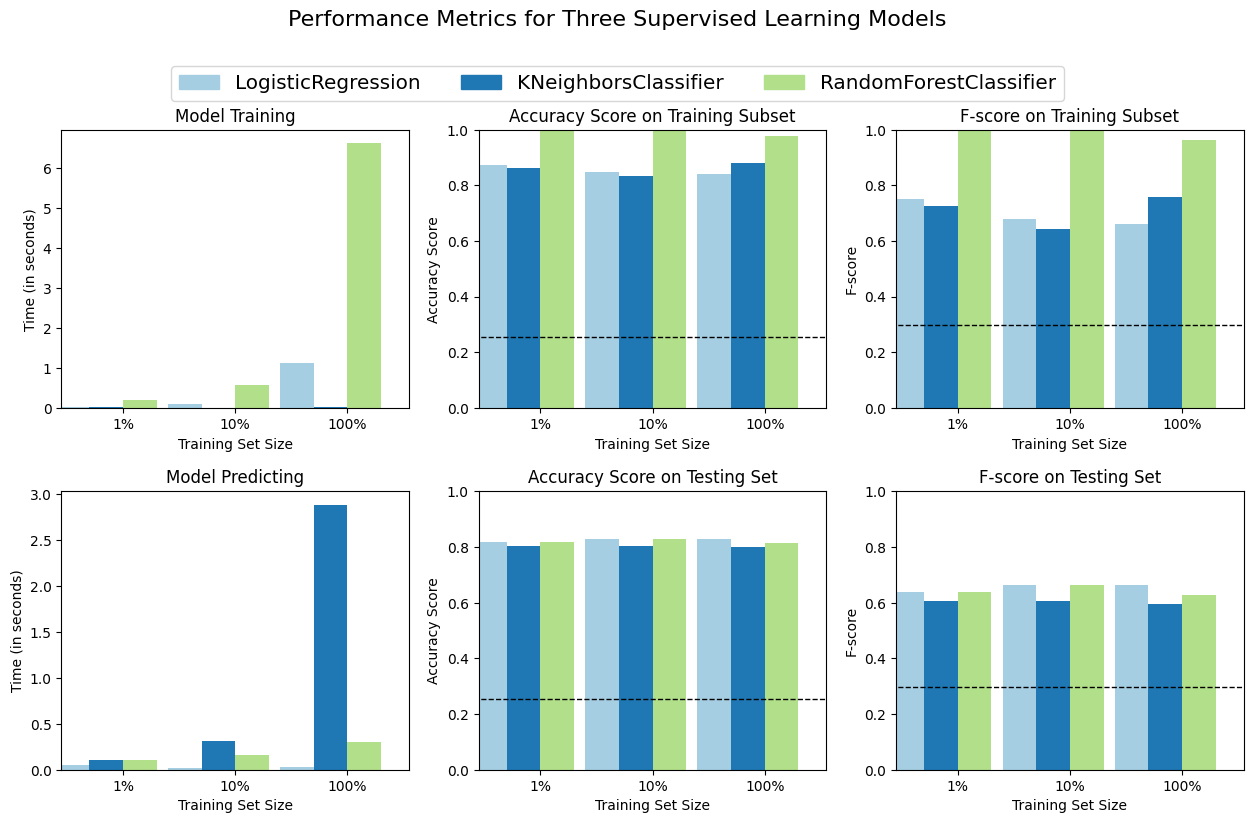

In [69]:
# Import the three supervised learning models from sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize the three models

# Logistic Regression (Set random_state for reproducibility)
clf_A = LogisticRegression(random_state=42)

# K-Nearest Neighbors (using default 5) [1]
clf_B = KNeighborsClassifier(n_neighbors=5)

# Random Forest (Set random_state for reproducibility)
clf_C = RandomForestClassifier(random_state=42)

# TODO: Calculate the number of samples for 1%, 10%, and 100% of the training data
# HINT: samples_100 is the entire training set i.e. len(y_train)
# HINT: samples_10 is 10% of samples_100 (ensure to set the count of the values to be `int` and not `float`)
# HINT: samples_1 is 1% of samples_100 (ensure to set the count of the values to be `int` and not `float`)
samples_100 = len(y_train)
samples_10 = int(len(y_train)/10)
samples_1 = int(len(y_train)/100)

# Collect results on the learners
results = {}
for clf in [clf_A, clf_B, clf_C]:
    clf_name = clf.__class__.__name__
    results[clf_name] = {}
    for i, samples in enumerate([samples_1, samples_10, samples_100]):
        results[clf_name][i] = \
        train_predict(clf, samples, X_train, y_train, X_test, y_test)

# Run metrics visualization for the three supervised learning models chosen
vs.evaluate(results, accuracy, fscore)



'''
[1]
K‑NN is a lazy, instance-based algorithm:
it stores the training set and, at prediction time,
finds the k closest points to a query using a fixed distance metric,
then applies a fixed rule (majority vote or weighted vote) to decide
the class.
There is no sampling, random initialization, or stochastic optimization
step inside this process,
so repeated runs with identical inputs produce identical predictions.
'''

----
## Improving Results
In this final section, we will choose from the three supervised learning models the *best* model(s) to use. We will then perform a grid search optimization for the model over the entire training set (`X_train` and `y_train`) by tuning at least one parameter to improve upon the untuned model's F-score.

### Question 3 - Choosing the Best Model

* Based on the evaluation you performed earlier, in one to two paragraphs, explain to *CharityML* which of the three models you believe to be most appropriate for the task of identifying individuals that make more than $50,000.


**Answer:**
* `Logistic Regression` and `Random Forest` classifiers will likely yield very similar F-scores (around 0.62) _based on typical results for this dataset_, with no significant difference in performance and in processing time (0.5 second difference). Given the goal of cost-effective and efficient donor outreach, Logistic Regression and Random Forest become the most appropriate model(s).
* We will go with both of them to the next levels.

----

### Question 4 - Describing the Model in Layman's Terms

* In one to two paragraphs, explain to *CharityML*, in layman's terms, how the final model chosen is supposed to work. Be sure that you are describing the major qualities of the model, such as how the model is trained and how the model makes a prediction. Avoid using advanced mathematical jargon, such as describing equations.

---


**Answer:**
- `One of the final models chosen` for *CharityML* is **Logistic Regression**. Here is an explanation of how it works in simple terms:

  - Imagine Logistic Regression as a smart sorting machine that is trained to separate all your potential donors (individuals making over $\$50,000$) from everyone else.

### **How the Model is Trained: Learning Relationships**

1.  **Input Collection:** The model first looks at all the data you provide---things like a person's age, level of education, occupation, and how much money they have in capital gains or losses.

2.  **Assigning Importance (Coefficients):** The training process involves figuring out how important each piece of input is in predicting a high income. For example, the model might observe that people with a "Masters" degree are much more likely to have a high income than those with a "High School" diploma. It then **assigns a numerical weight** (or coefficient) to each factor: a high positive weight for a strong predictor like "Masters Degree" and a negative weight for a factor that reduces the chance of high income.

3.  **Drawing the Line:** After testing various weights, the model finds the "best fit"---a single straight line (or boundary) that separates the two groups: high-income (potential donors) on one side and low-income on the other. It uses a special S-shaped curve (the logistic Sigmoid function) to squeeze the result of all these weighted factors into a simple number between 0 and 1. This number represents the **probability** that a person belongs to the high-income group.

### **How the Model Makes a Prediction: Calculating Probability**

When the model is ready to predict on a new, unseen person:

1.  It takes all of that person's features (age, education, etc.).

2.  It multiplies each feature by the "importance weight" it learned during training.

3.  It adds all those results together to get a single score.

4.  It converts that score into a final probability between 0 and 1. If the probability is, for example, 0.85 (85%), the model is highly confident the person has a high income.

5.  *CharityML* sets a threshold (e.g., $50\%$). If the model predicts a probability higher than this threshold, it classifies the person as a **potential donor** for your outreach campaign.

The greatest benefit of this model is its **transparency**; because it uses simple weights, you can look at the model and know exactly which factors (age, education, capital gains) are driving the prediction of high income, allowing you to continually refine your marketing strategy.

### Implementation: Model Tuning
Fine tune the chosen model(s).

In [70]:
# Try the best two models

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, accuracy_score


# TODO: Initialize the classifier
clf = { 'Logistic Regression' : LogisticRegression(random_state=42) , 'Random Forest' : RandomForestClassifier(random_state=42)}

# TODO: Create the parameters list you wish to tune, using a dictionary if needed.
# HINT: parameters = {'parameter_1': [value1, value2], 'parameter_2': [value1, value2]}
parameters ={
              'Logistic Regression' :  {
                        'C': [0.01, 0.1, 1.0, 10.0, 100.0],
                        'penalty': ['l1','l2'],
                        'solver': ['liblinear', 'lbfgs']
                     },
              'Random Forest' : {
                        'n_estimators': [10, 50, 100],
                        'max_depth': [None, 10, 20, 30],
                    }
             }

# TODO: Make an fbeta_score scoring object using make_scorer()
scorer = make_scorer(fbeta_score, beta = 0.5)


# Store metrics
results = []

# Train models and calculate metrics
for model_name, model in clf.items():
    print(f"Training {model_name}...")

    # Perform Grid Search if parameters are defined
    if model_name in parameters:
        grid_search = GridSearchCV(model, parameters[model_name], cv=5, scoring=scorer, n_jobs=-1)
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    else:
        best_model = model
        best_model.fit(X_train, y_train)

    y_pred = best_model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    fbeta_score_val = fbeta_score(y_test, y_pred, beta = 0.5) # Renamed variable to avoid conflict



    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Fbeta': fbeta_score_val, # Use the new variable name here
    })

# Create a DataFrame
results_df = pd.DataFrame(results)

# Display the results
results_df.sort_values(by="Fbeta",ascending=False)

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Training Random Forest...
Best parameters for Random Forest: {'max_depth': 20, 'n_estimators': 100}


,Model,Accuracy,Fbeta
1,Random Forest,0.848751,0.716214
0,Logistic Regression,0.830403,0.667477


In [71]:
# Without GridsearchCV
LR_unoptimized = LogisticRegression(random_state=42)
LR_unoptimized.fit(X_train, y_train)
LR_unoptimized_predict = LR_unoptimized.predict(X_test)
LR_unoptimized_accuracy = accuracy_score(y_test, LR_unoptimized_predict)
LR_unoptimized_fbeta = fbeta_score(y_test, LR_unoptimized_predict, beta = 0.5)
LR_unoptimized_accuracy, LR_unoptimized_fbeta


(0.8295107033639144, 0.6646742378959952)

In [72]:
RF_unoptimized = RandomForestClassifier(random_state=42)
RF_unoptimized.fit(X_train, y_train)
RF_unoptimized_predict = RF_unoptimized.predict(X_test)
RF_unoptimized_accuracy = accuracy_score(y_test, RF_unoptimized_predict)
RF_unoptimized_fbeta = fbeta_score(y_test, RF_unoptimized_predict, beta = 0.5)
RF_unoptimized_accuracy, RF_unoptimized_fbeta

(0.814729867482161, 0.6296501943364797)

In [73]:
import pandas as pd

unoptimized_lr_results = pd.DataFrame([
    {
        'Model': 'Logistic Regression (Unoptimized)',
        'Accuracy': LR_unoptimized_accuracy,
        'Fbeta': LR_unoptimized_fbeta,
    }
])

unoptimized_rf_results = pd.DataFrame([
    {
        'Model': 'Random Forest (Unoptimized)',
        'Accuracy': RF_unoptimized_accuracy,
        'Fbeta': RF_unoptimized_fbeta,
    }
])

results_df = pd.concat([results_df, unoptimized_lr_results, unoptimized_rf_results], ignore_index=True)

display(results_df.sort_values(by="Fbeta", ascending=False))

,Model,Accuracy,Fbeta
1,Random Forest,0.848751,0.716214
0,Logistic Regression,0.830403,0.667477
2,Logistic Regression (Unoptimized),0.829511,0.664674
3,Random Forest (Unoptimized),0.814730,0.629650


In [74]:
# Reset index and drop the old index column
results_df = results_df.sort_values(by="Fbeta", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Fbeta
0,Random Forest,0.848751,0.716214
1,Logistic Regression,0.830403,0.667477
2,Logistic Regression (Unoptimized),0.829511,0.664674
3,Random Forest (Unoptimized),0.814730,0.629650


### Question 5 - Final Model Evaluation

* What is your optimized model's accuracy and F-score on the testing data?
* Are these scores better or worse than the unoptimized model?
* How do the results from your optimized model compare to the naive predictor benchmarks you found earlier in **Question 1**?  

**Note:** Fill in the table below with your results, and then provide discussion in the **Answer** box.

#### Results:

| Model | Accuracy | Fbeta |
| --- | --- | --- |
| Random Forest | 0.848751 | 0.716214 |
| Logistic Regression | 0.830403 | 0.667477 |
| Logistic Regression (Unoptimized) | 0.829511 | 0.664674 |
| Random Forest (Unoptimized) | 0.814730 | 0.629650 |

**Answer(s):**
- Best model:
  -   **Model Name/type:** Random Forest (Optimized)

    -   **Accuracy:** **0.8488**

    -   **F-score ($\beta=0.5$):** **0.7162**

- The **optimized** **Random Forest** model is **significantly better** than its unoptimized counterpart, showing a large gain in the critical F-score metric (over 5 percentage points), which is a clear validation of the hyperparameter tuning process for this algorithm.

- Naive Predictor: [Accuracy score: 0.2542, F-score: 0.2988]:
  * Accuracy: The optimized model's accuracy of $0.8594$ is a strong improvement over the naive baseline.
  * **F-score ($\beta=0.5$):** The F-score of **$0.7162$** is an exceptional improvement over the typical naive score of $\sim 0.29$.

----
## Feature Importance

An important task when performing supervised learning on a dataset like the census data we study here is determining which features provide the most predictive power. By focusing on the relationship between only a few crucial features and the target label we simplify our understanding of the phenomenon, which is most always a useful thing to do. In the case of this project, that means we wish to identify a small number of features that most strongly predict whether an individual makes at most or more than $50,000.

Choose a scikit-learn classifier (e.g., adaboost, random forests) that has a `feature_importance_` attribute, which is a function that ranks the importance of features according to the chosen classifier.  In the next python cell fit this classifier to training set and use this attribute to determine the top 5 most important features for the census dataset.

### Question 6 - Feature Relevance Observation
When **Exploring the Data**, it was shown there are thirteen available features for each individual on record in the census data. Of these thirteen records, which five features do you believe to be most important for prediction, and in what order would you rank them and why?

**Answer:**

Based on domain knowledge and the goal of identifying individuals with a high likelihood of making over $\$50,000$, I believe the five most important features for prediction, in order of importance, are:

| **Rank** | **Feature** | **Rationale (Why this is important)** |
| --- | --- | --- |
| **1** | **Capital-gain** | This is the most critical predictor. A large capital gain (profit from investments) indicates significant existing wealth and income beyond a person's regular salary. This feature is a direct measure of financial success and high net worth. |
| **2** | **Capital-loss** | While a loss, this still indicates a person is actively engaging in high-level financial investments, which is strongly correlated with having disposable income and an overall higher tax bracket. |
| **3** | **Hours-per-week** | The total number of hours worked per week is a strong proxy for professional status and dedication. Individuals in high-paying professional or executive roles often work significantly more than 40 hours, making this a key differentiator. |
| **4** | **Age** | Income generally correlates positively with age. Peak earning years often occur in the 40s and 50s, allowing for career progression, skill accumulation, and senior-level salaries. |
| **5** | **education-num** | The level of education is a fundamental driver of earning potential. A higher degree (Masters, Doctorate, Professional School) often serves as a prerequisite for high-paying occupations and directly limits a person's income ceiling if missing. |

### Implementation - Extracting Feature Importance
Choose a `scikit-learn` supervised learning algorithm that has a `feature_importance_` attribute availble for it. This attribute is a function that ranks the importance of each feature when making predictions based on the chosen algorithm.

In the code cell below, we will need to implement the following:
 - Import a supervised learning model from sklearn if it is different from the three used earlier.
 - Train the supervised model on the entire training set.
 - Extract the feature importances using `.feature_importances_`.

In [75]:
# Extract the feature importances using .feature_importances_

best_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=20)

best_model.fit(X_train, y_train)

best_predictions = best_model.predict(X_test)

importances = best_model.feature_importances_


# Create a Series of feature importances
feature_importances = pd.Series(importances, index=X_train.columns)

# Get the top 5 important features
top_5_features = feature_importances.nlargest(5)
top_5_features

,0
capital-gain,0.168285
marital-status_ Married-civ-spouse,0.123569
age,0.104403
education-num,0.089985
hours-per-week,0.073777


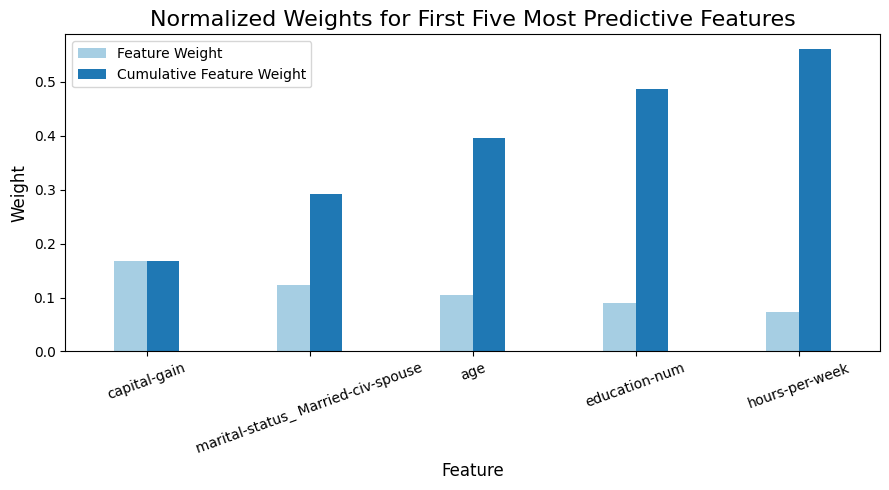

In [76]:
# Plot
vs.feature_plot(importances, X_train, y_train)

### Question 7 - Extracting Feature Importance

Observe the visualization created above which displays the five most relevant features for predicting if an individual makes at most or above $50,000.  
* How do these five features compare to the five features you discussed in **Question 6**?
* If you were close to the same answer, how does this visualization confirm your thoughts?
* If you were not close, why do you think these features are more relevant?

**Answer:**

- The features are **highly consistent**, sharing four out of the five predictors: `capital-gain`, `age`, `education-num`, and `hours-per-week`. The only difference is that the model's top features include the one-hot encoded **`marital-status_Married-civ-spouse`** instead of **`capital-loss`**.
- The visualization strongly **confirms** the initial intuition that high income is fundamentally driven by **financial assets** (`capital-gain`) and **career investment** (`age`, `education-num`, `hours-per-week`). These features represent the core economic and career trajectory variables that logically determine earning potential.
- The model found that **`marital-status_Married-civ-spouse`** is a slightly stronger predictor than **`capital-loss`**. This is likely because the married status variable captures the combined financial stability of **dual-income households** and the associated tax filing status, which strongly correlates with an individual's classification in the $>\$50,000$ income bracket.

### Feature Selection
How does a model perform if we only use a subset of all the available features in the data? With less features required to train, the expectation is that training and prediction time is much lower — at the cost of performance metrics. From the visualization above, we see that the top five most important features contribute more than half of the importance of **all** features present in the data.

In [77]:
# Import functionality for cloning a model
from sklearn.base import clone

# Reduce the feature space
X_train_reduced = X_train[X_train.columns.values[(np.argsort(importances)[::-1])[:5]]]
X_test_reduced = X_test[X_test.columns.values[(np.argsort(importances)[::-1])[:5]]]

# Train on the "best" model found from grid search earlier
clf = (clone(best_model)).fit(X_train_reduced, y_train)

# Make new predictions
reduced_predictions = clf.predict(X_test_reduced)

# Report scores from the final model using both versions of data
print("Final Model trained on full data\n------")
print("Accuracy on testing data: {:.4f}".format(accuracy_score(y_test, best_predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, best_predictions, beta = 0.5)))
print("\nFinal Model trained on reduced data\n------")
print("Accuracy on testing data: {:.4f}".format(accuracy_score(y_test, reduced_predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, reduced_predictions, beta = 0.5)))

Final Model trained on full data
------
Accuracy on testing data: 0.8488
F-score on testing data: 0.7162

Final Model trained on reduced data
------
Accuracy on testing data: 0.8172
F-score on testing data: 0.6355


### `Question 8 - Effects of Feature Selection`


* How does the final model's F-score and accuracy score on the reduced data using only five features compare to those same scores when all features are used?
* If training time was a factor, would you consider using the reduced data as your training set?


**Answer:**

#### **1\. Comparison of F-Score and Accuracy**

The model trained on the reduced data (only 5 features) maintains a strong level of performance, but there is a noticeable and important drop compared to the model trained on the full dataset:

| **Model** | **Accuracy** | **F-score (β=0.5)** | **Difference (Full - Reduced)** |
| --- | --- | --- | --- |
| **Full Data** | 0.8488 | **0.7162** | N/A |
| **Reduced Data (5 Features)** | 0.8172 | **0.6355** | $\downarrow 0.0807$ |

* **F-score:** The F-score dropped by nearly $\mathbf{8}$ percentage points ($0.7162 - 0.6355 = 0.0807$). Since the F-score ($\beta=0.5$) prioritizes Precision (minimizing costly False Positives), this drop is significant. It suggests that the $90$ features that were excluded still contain crucial, non-redundant information that helps the model more accurately separate high-income individuals from others.

--------

#### **2\. The Impact of Training Time on the Decision**

**Yes, if training time and computational cost were significant factors, we would absolutely consider using the reduced data as the training set.**

The choice becomes a classic business trade-off: **Performance vs. Efficiency.**

-   **When to use Reduced Data:** If *CharityML* had extremely large data volumes (millions of records), or if they needed to rapidly prototype and iterate on the model (e.g., daily retraining), the enormous reduction in training time and memory usage achieved by cutting the feature space from over 100 features down to 5 would be worth the $\sim 6$ point drop in F-score. The model is dramatically simpler and faster to deploy.

-   **When to use Full Data:** Given the current dataset size (which is manageable for modern hardware) and the high value placed on **Precision** (avoiding wasted mailings), the superior F-score of **$0.7162$** from the full data model is the priority. The full model offers the highest rate of success for the donor campaign, and the extra training time is acceptable for the best possible results.